<a href="https://colab.research.google.com/github/Enricobs/Data_Analytics_02/blob/main/Estudos_QualidadeVinhos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge -  2
## Classificação da qualidade de vinhos utilizando Machine Learning

1. Compreensão do problema
2. Importação das bibliotecas
3. Carregamento e inspeção inicial dos dados
4. Criação da variável quality_binary
5. Análise Exploratória dos Dados
6. Pré-processamento
7. Regressão Logística
8. Random Forest
9. Comparação dos modelos
10. Importância das variáveis
11. Conclusões

In [84]:
# MANIPULAÇÃO DE DADOS BASICA
import pandas as pd
import numpy as np

# VISUALIZAÇÃO DE DADOS
import matplotlib.pyplot as plt
import seaborn as sns

#STYLE- G1
plt.style.use('default')
sns.set_theme(style="whitegrid")

# PRÉ-PROCESSAMENTO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# MODELOS DE MACHINE LEARNING - T1
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier


# MÉTRICAS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# VALIDAÇÃO
from sklearn.model_selection import cross_val_score

# IMPORTÂNCIA DAS FEATURES
from sklearn.inspection import permutation_importance



# Configuração do Pandas - Padronização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuração dos gráficos - Padronização
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 11


In [45]:
# Carregar o dataset
df = pd.read_csv("WineQT.csv")


In [46]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [47]:
print(f'{df.shape}')

(1143, 13)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [50]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [51]:
print(f'{df.duplicated().sum()}')

0


In [52]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

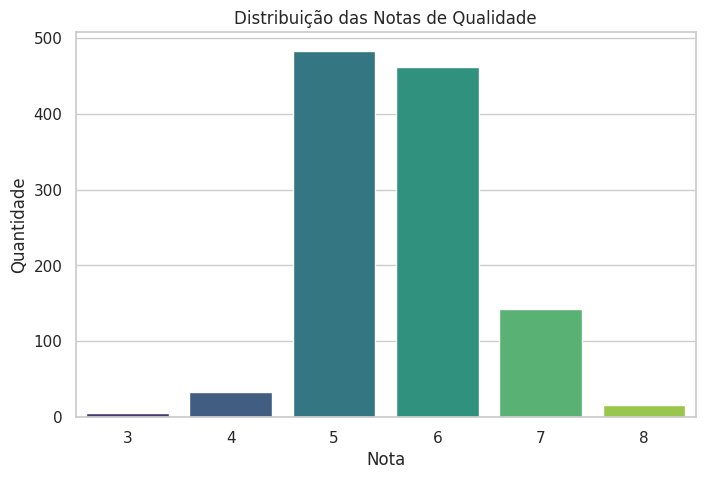

In [53]:
# Tem mais vinhos com Nota Alta ou Baixa?

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='quality',
    palette='viridis'
)

plt.title('Distribuição das Notas de Qualidade')
plt.xlabel('Nota')
plt.ylabel('Quantidade')

plt.show()

In [54]:
#Criando a variável para avaliação dos Vinhos >= 7

df['quality_binary'] = np.where(df['quality'] >= 7, 1, 0)


In [55]:
#Vendo se esta demonstrando correto

df[['quality','quality_binary']].head(10)

,quality,quality_binary
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


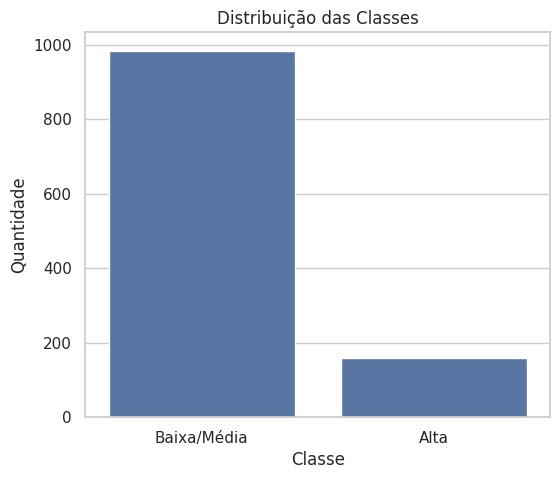

In [56]:
#Realmente existem muitos mais vinhos Notas 6 que vinhos Nota 7+?

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='quality_binary'
)

plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

plt.xticks([0,1], ['Baixa/Média','Alta'])

plt.show()

In [57]:
##Quantidade Total

df['quality_binary'].value_counts()

,count
quality_binary,
0,984
1,159


In [58]:
## Porcentagem

round(df['quality_binary'].value_counts(normalize=True)*100,2)

,proportion
quality_binary,
0,86.09
1,13.91


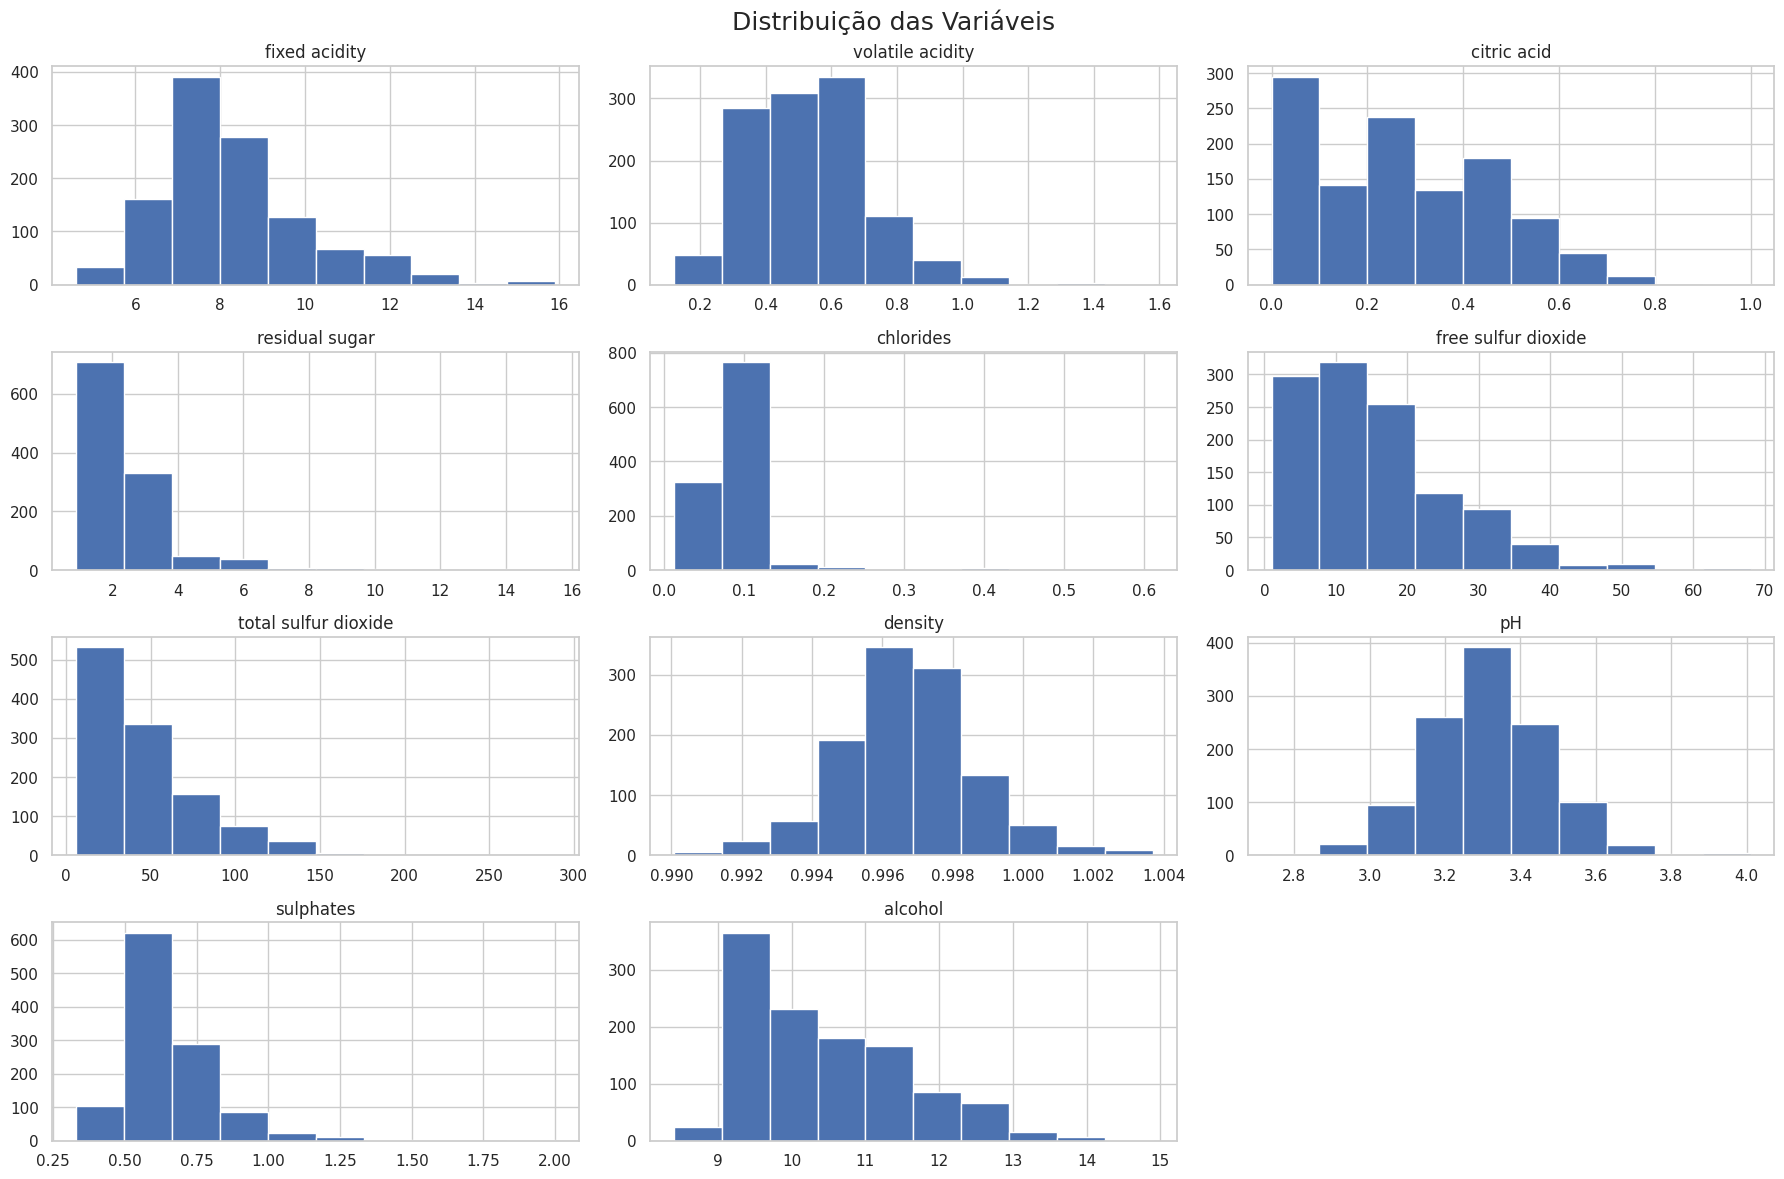

In [59]:
# Tirar a Coluna ID, tirar as duas colunas que já temos as informações e graficos
df_eda = df.drop(columns=['Id', 'quality_binary', 'quality'])

# Histogramas de todas as variáveis, nem sabia que dava para fazer mas é de genio e salva muito tempo Ed vc é o cara
df_eda.hist(figsize=(18, 12))

plt.suptitle("Distribuição das Variáveis", fontsize=18)
plt.tight_layout()
plt.show()

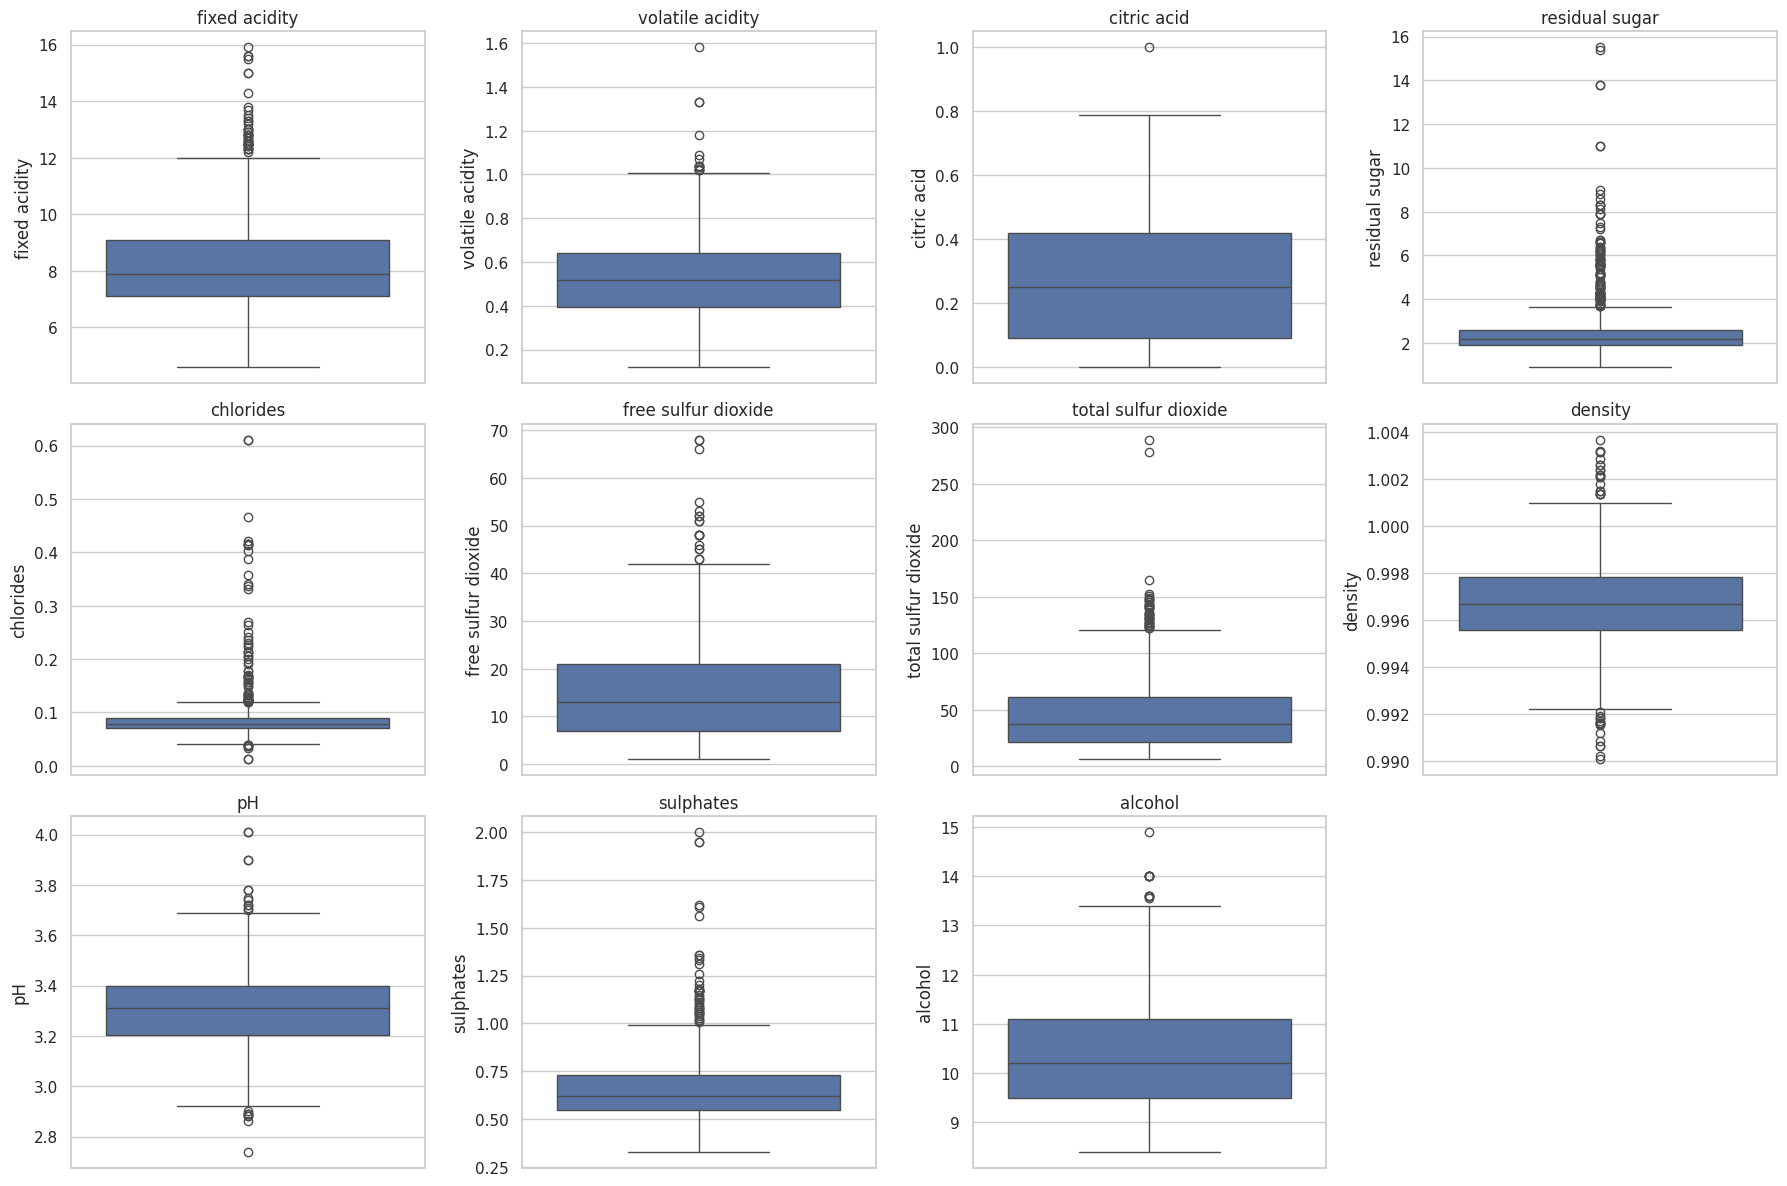

In [60]:
#Verficiando Outliners com Boxplots
plt.figure(figsize=(18,12))

for i, coluna in enumerate(df.drop(columns=['Id', 'quality', 'quality_binary']).columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[coluna])
    plt.title(coluna)

plt.tight_layout()
plt.show()

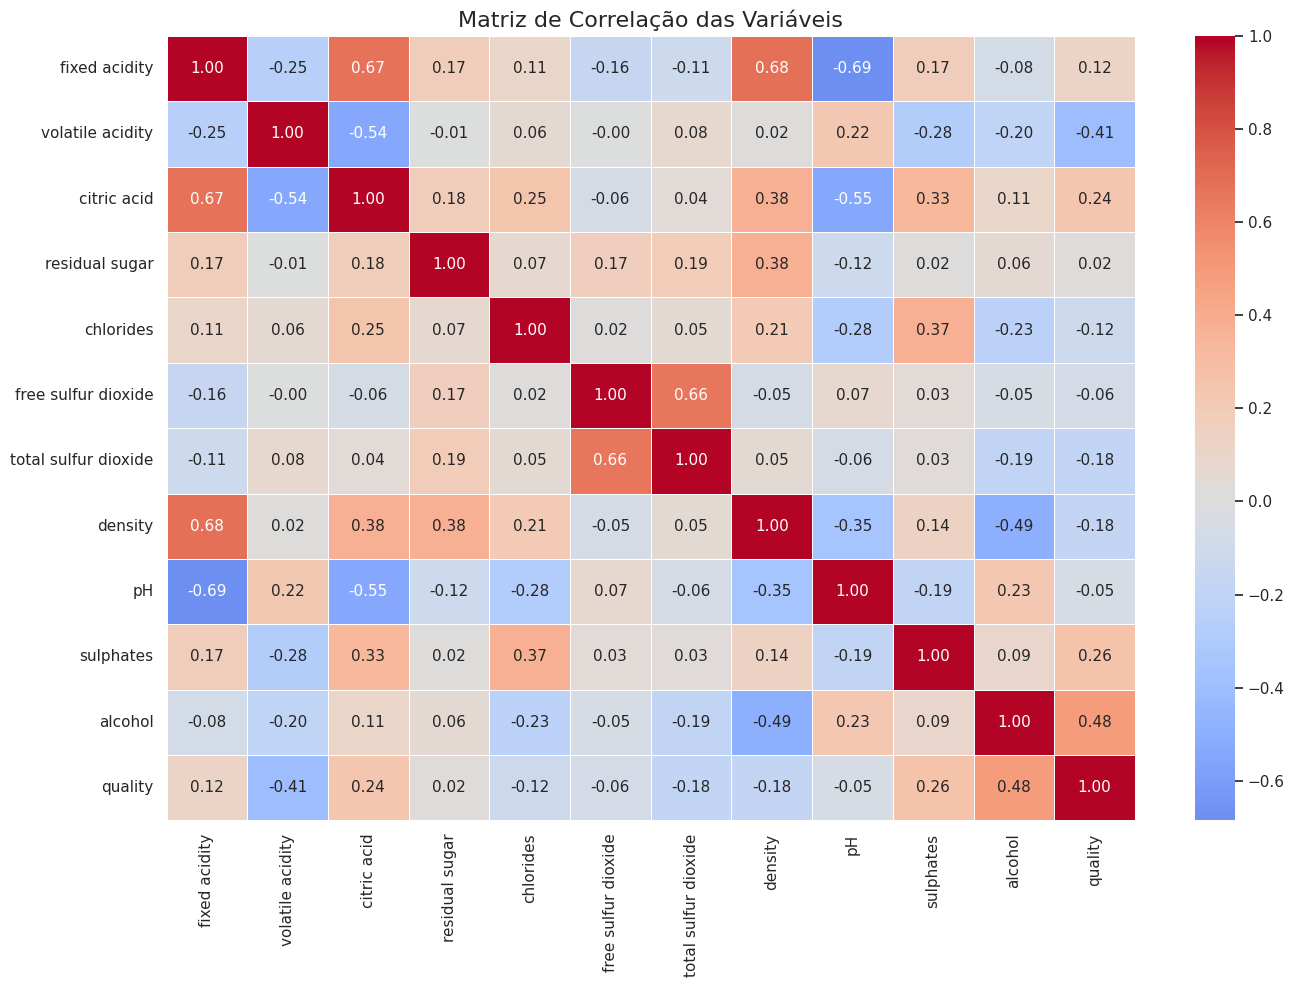

In [61]:
# Selecionar variáveis para Matriz de correlação
df_corr = df.drop(columns=['Id', 'quality_binary'])

# Matriz de correlação
corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title(
    'Matriz de Correlação das Variáveis',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [62]:
correlacao_quality = (
    corr_matrix['quality']
    .drop('quality')
    .sort_values(ascending=False)
)

print(correlacao_quality)

alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


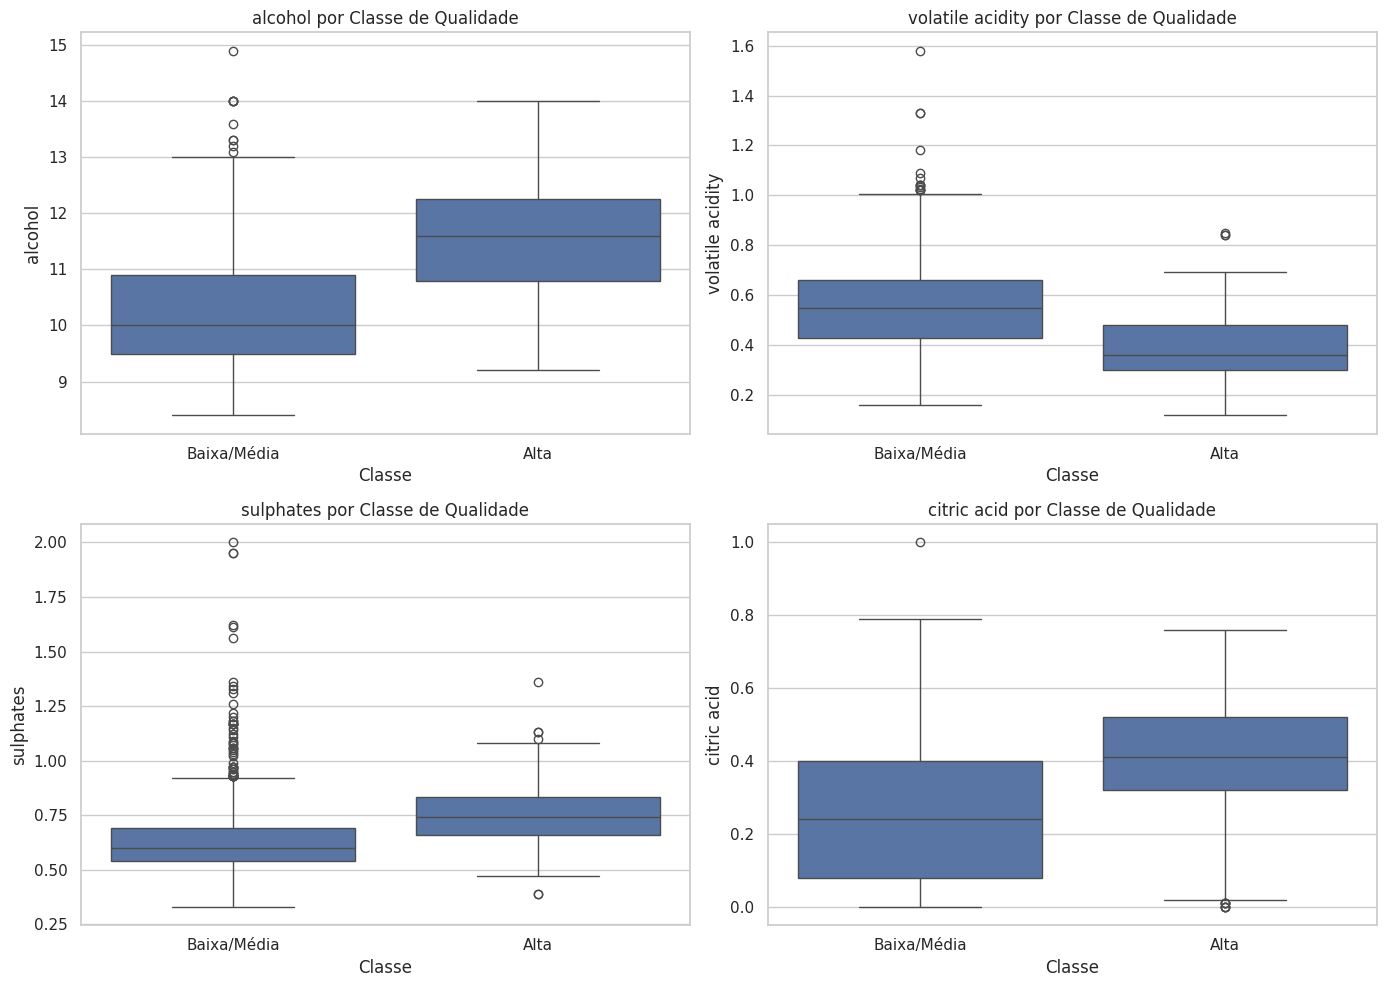

In [63]:
variaveis_principais = [
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid'
]

plt.figure(figsize=(14, 10))

for i, coluna in enumerate(variaveis_principais, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x='quality_binary',
        y=coluna
    )

    plt.title(f'{coluna} por Classe de Qualidade')
    plt.xlabel('Classe')
    plt.xticks([0, 1], ['Baixa/Média', 'Alta'])

plt.tight_layout()
plt.show()

In [64]:
#Organizando para fazer processamento de dados
X = df.drop(columns=[ 'Id','quality','quality_binary'])

y = df['quality_binary']

print(" X:", X.shape)
print(" Y:", y.shape)

print("Variáveis utilizadas:")
print(X.columns.tolist())

 X: (1143, 11)
 Y: (1143,)
Variáveis utilizadas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=77,
    stratify=y
)

print(X_train.shape)
print( X_test.shape)
print( y_train.shape)
print( y_test.shape)

(914, 11)
(229, 11)
(914,)
(229,)


In [66]:
print("Distribuição no conjunto de treino:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Distribuição no conjunto de teste:")
print(y_test.value_counts(normalize=True).mul(100).round(2)
)

Distribuição no conjunto de treino:
quality_binary
0    86.11
1    13.89
Name: proportion, dtype: float64
Distribuição no conjunto de teste:
quality_binary
0    86.03
1    13.97
Name: proportion, dtype: float64


In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Padronização concluída.")
print("Treino:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)

Padronização concluída.
Treino: (914, 11)
Teste: (229, 11)


In [68]:
scaler.fit_transform(X_train)

array([[ 0.48867736, -0.89326384,  0.28691789, ..., -0.09411042,
         0.85249164,  0.71468915],
       [-1.07041506, -0.9487702 ,  1.36737736, ...,  0.36066184,
         1.63764827,  1.84377962],
       [-0.89718257,  0.60540806, -0.17613617, ...,  0.29569437,
         0.248525  ,  0.43241653],
       ...,
       [-0.78169424,  0.16135713, -1.20514519, ...,  1.40014129,
        -0.53663163,  0.15014391],
       [-0.3774851 ,  1.16047173, -1.35949654, ...,  0.29569437,
        -0.4158383 ,  0.52650741],
       [ 3.02942056, -0.00516197,  2.70508908, ..., -0.87372001,
         0.67130165,  2.40832486]])

In [69]:
scaler.transform(X_test)

array([[ 0.31544487, -0.67123837,  1.93333232, ...,  1.46510876,
         0.00693835,  0.05605304],
       [ 0.43093319, -0.33820017,  0.23546744, ..., -0.02914296,
        -0.29504497, -0.97894656],
       [ 0.2577007 , -0.615732  ,  0.95577375, ...,  0.10079198,
         0.67130165,  1.46741613],
       ...,
       [-0.03102011,  0.16135713, -0.17613617, ..., -0.22404535,
        -0.23464831, -0.97894656],
       [-0.31974093,  1.35474401,  0.8014224 , ..., -0.54888268,
        -0.4158383 , -0.88485569],
       [-0.8394384 ,  0.66091443, -1.25659564, ...,  0.23072691,
        -0.23464831, -0.03803783]])

In [70]:
# Modelo de Regressão
modelo_lr = LogisticRegression(
    class_weight='balanced',
    random_state=77,
    max_iter=1000
)

# Treinamento com os dados
modelo_lr.fit(X_train_scaled, y_train)

# Previsões
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Probabilidades
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print("Treinado e Probabilidades Feitas.")

Treinado e Probabilidades Feitas.


In [71]:
# Métricas da Regressão Logística
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("REGRESSÃO LOGÍSTICA")
print("-" * 35)
print(f"Acurácia:  {accuracy_lr:.4f}")
print(f"Precisão:  {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

REGRESSÃO LOGÍSTICA
-----------------------------------
Acurácia:  0.7991
Precisão:  0.3971
Recall:    0.8438
F1-Score:  0.5400
ROC-AUC:   0.8964


In [72]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ]
    )
)

                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.97      0.79      0.87       197
       Alta Qualidade       0.40      0.84      0.54        32

             accuracy                           0.80       229
            macro avg       0.68      0.82      0.71       229
         weighted avg       0.89      0.80      0.83       229



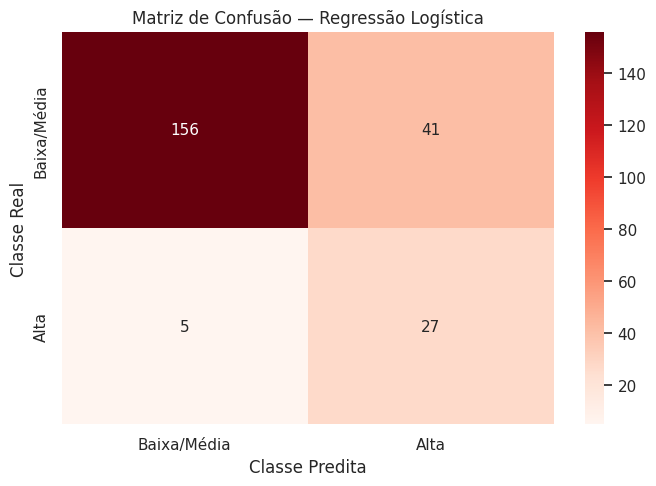

In [73]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Baixa/Média', 'Alta'],
    yticklabels=['Baixa/Média', 'Alta']
)

plt.title('Matriz de Confusão — Regressão Logística')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')

plt.tight_layout()
plt.show()

In [74]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=77,
    n_jobs=-1
)

#Treinamento
modelo_rf.fit(X_train, y_train)

#Previsões
y_pred_rf = modelo_rf.predict(X_test)

#Probabilidades da positiva
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [75]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST")
print("-" * 35)
print(f"Acurácia:  {accuracy_rf:.4f}")
print(f"Precisão:  {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

RANDOM FOREST
-----------------------------------
Acurácia:  0.9170
Precisão:  0.7826
Recall:    0.5625
F1-Score:  0.6545
ROC-AUC:   0.9251


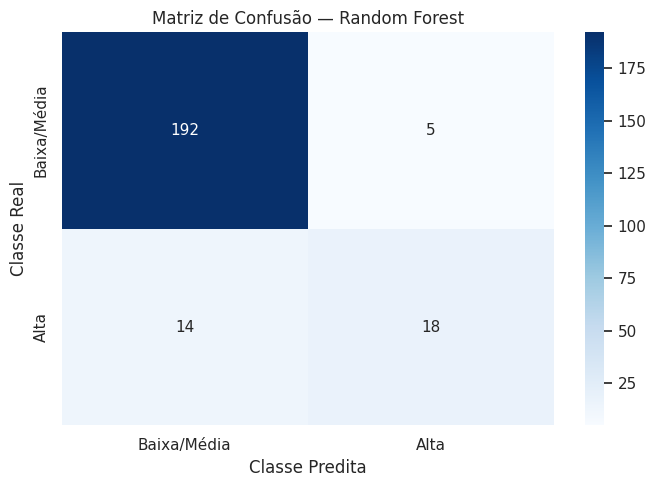

In [76]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Baixa/Média', 'Alta'],
    yticklabels=['Baixa/Média', 'Alta']
)

plt.title('Matriz de Confusão — Random Forest')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')

plt.tight_layout()
plt.show()

In [77]:
#Comparação entre os Dois Modelos Utilizados
resultados = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Random Forest'
    ],

    'Acurácia': [
        accuracy_lr,
        accuracy_rf
    ],

    'Precisão': [
        precision_lr,
        precision_rf
    ],

    'Recall': [
        recall_lr,
        recall_rf
    ],

    'F1-Score': [
        f1_lr,
        f1_rf
    ],

    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_rf
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
0,Regressão Logística,0.799127,0.397059,0.84375,0.540000,0.896415
1,Random Forest,0.917031,0.782609,0.56250,0.654545,0.925127


In [78]:
#Decimais menores
resultados.round(4)

,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
0,Regressão Logística,0.7991,0.3971,0.8438,0.5400,0.8964
1,Random Forest,0.9170,0.7826,0.5625,0.6545,0.9251


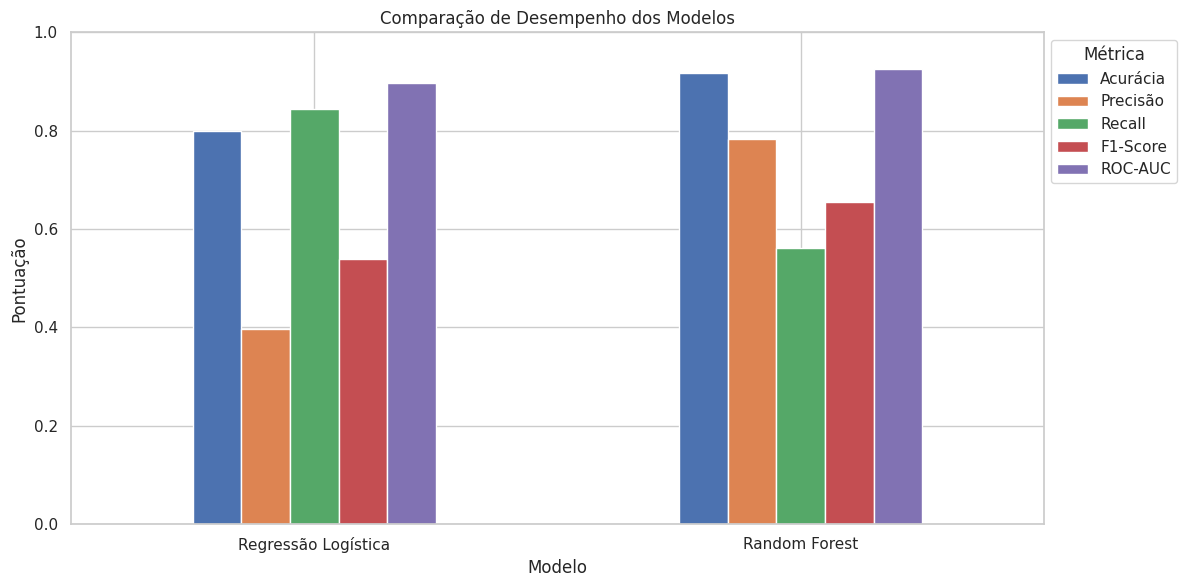

In [79]:
resultados_plot = resultados.set_index('Modelo')

resultados_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Comparação de Desempenho dos Modelos')
plt.ylabel('Pontuação')
plt.xlabel('Modelo')
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title='Métrica',
    bbox_to_anchor=(1,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [80]:
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by='Importância',
    ascending=False
)

importancias

,Variável,Importância
10,alcohol,0.193883
9,sulphates,0.142323
1,volatile acidity,0.140550
2,citric acid,0.099646
7,density,0.080997
4,chlorides,0.069669
0,fixed acidity,0.066406
6,total sulfur dioxide,0.062691
8,pH,0.053241
3,residual sugar,0.045999


In [81]:
importancias.round(4)

,Variável,Importância
10,alcohol,0.1939
9,sulphates,0.1423
1,volatile acidity,0.1406
2,citric acid,0.0996
7,density,0.0810
4,chlorides,0.0697
0,fixed acidity,0.0664
6,total sulfur dioxide,0.0627
8,pH,0.0532
3,residual sugar,0.0460


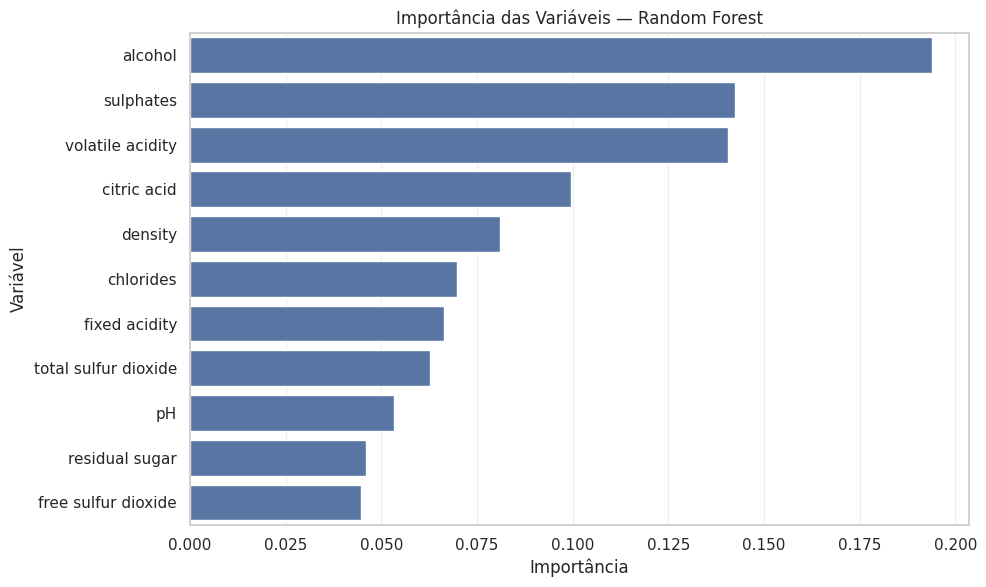

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias,
    x='Importância',
    y='Variável'
)

plt.title('Importância das Variáveis — Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')

plt.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [83]:
importancias_final = importancias.copy()

importancias_final['Importância'] = (
    importancias_final['Importância']
    .round(4)
)

importancias_final

,Variável,Importância
10,alcohol,0.1939
9,sulphates,0.1423
1,volatile acidity,0.1406
2,citric acid,0.0996
7,density,0.0810
4,chlorides,0.0697
0,fixed acidity,0.0664
6,total sulfur dioxide,0.0627
8,pH,0.0532
3,residual sugar,0.0460
